In [1]:
# imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [3]:
# Importing our modules

In [4]:
df = pd.read_csv("df_features.csv")  
df.head()
df.columns


Index(['customer_id', 'gender', 'age', 'tenure', 'monthlycharges',
       'paymentmethod', 'churn', 'industry'],
      dtype='object')

In [5]:
# preprocess features

In [15]:
numeric_features = ['age', 'tenure', 'monthlycharges']
categorical_features = ['gender', 'paymentmethod', 'industry']
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop='first')      # drop first to avoid dummy variable trap

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

X = preprocessor.fit_transform(df)  # Transform features for clustering


In [16]:
# Get categorical column names after one-hot encoding
ohe_columns = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)

# Combine with numeric feature names
all_columns = numeric_features + list(ohe_columns)

# Convert transformed array to DataFrame
X_df = pd.DataFrame(X.toarray() if hasattr(X, "toarray") else X, columns=all_columns)

# Show first 5 rows
X_df.head()

,age,tenure,monthlycharges,gender_Male,paymentmethod_Cash on Delivery,paymentmethod_Credit Card,paymentmethod_Credit card (automatic),paymentmethod_Debit Card,paymentmethod_Electronic check,paymentmethod_Mailed check,paymentmethod_Net Banking,paymentmethod_PayPal,paymentmethod_UPI,industry_Subscription,industry_Telecom
0,-0.371853,-1.511772,-1.155154,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.103853,0.076123,-0.136535,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,-1.376852,-1.463654,-0.253056,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,-1.443852,0.605421,-0.687190,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-1.577852,-1.463654,0.380292,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [28]:
# Check X_dense
print("X_dense type:", type(X_dense))
print("X_dense shape:", X_dense.shape)
print("Any NaN values?", np.isnan(X_dense).any())

# If everything looks fine, try clustering
print("Running KMeans for k=3...")
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(X_dense)
score = silhouette_score(X_dense, labels)
print(f"Silhouette score for k={k}:", score)


X_dense type: <class 'numpy.ndarray'>
X_dense shape: (21129, 15)
Any NaN values? False
Running KMeans for k=3...
Silhouette score for k=3: 0.16098269421685993


In [ ]:
# Assign cluster labels to your DataFrame

In [30]:
# Assign cluster labels to df
df['Segment'] = labels

# Check first 5 rows
df[['customer_id', 'Segment']].head(100)

,customer_id,Segment
0,TEL_7590-VHVEG,0
1,TEL_5575-GNVDE,0
2,TEL_3668-QPYBK,0
3,TEL_7795-CFOCW,2
4,TEL_9237-HQITU,1
...,...,...
95,TEL_8637-XJIVR,1
96,TEL_9803-FTJCG,2
97,TEL_0278-YXOOG,0
98,TEL_3212-KXOCR,2


In [33]:
df['Segment'] = labels 

In [ ]:
# Customer Lifetime Value

In [34]:
df['CLV'] = df['monthlycharges'] * df['tenure']

# scale CLV for visualization
from sklearn.preprocessing import StandardScaler
df['CLV_scaled'] = StandardScaler().fit_transform(df[['CLV']])

# Check first few rows
df[['customer_id', 'Segment', 'CLV', 'CLV_scaled']].head()

,customer_id,Segment,CLV,CLV_scaled
0,TEL_7590-VHVEG,0,29.85,-1.124081
1,TEL_5575-GNVDE,0,1936.30,-0.076050
2,TEL_3668-QPYBK,0,107.70,-1.081284
3,TEL_7795-CFOCW,2,1903.50,-0.094081
4,TEL_9237-HQITU,1,141.40,-1.062758


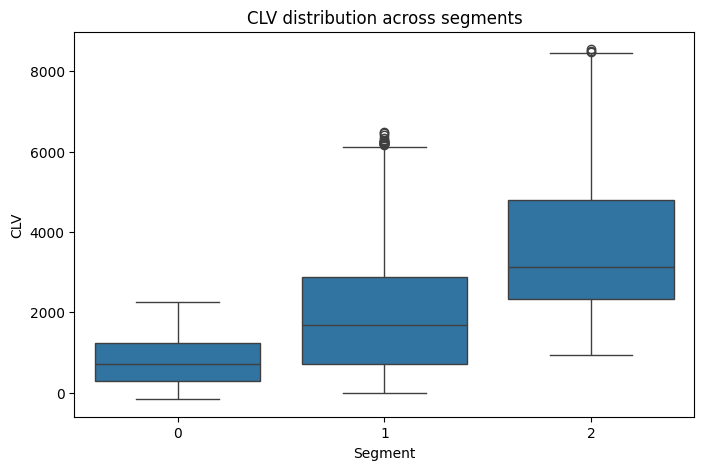

In [35]:
# Boxplot of CLV by segment
plt.figure(figsize=(8,5))
sns.boxplot(x='Segment', y='CLV', data=df)
plt.title("CLV distribution across segments")
plt.show()

In [39]:
# Group by Segment
segment_summary = df.groupby('Segment').agg({
    'customer_id': 'count',           # Number of customers
    'age': 'mean',                    # Average age
    'tenure': 'mean',                 # Average tenure
    'monthlycharges': 'mean',         # Average monthly charges
    'CLV': ['mean', 'sum']            # Average and total CLV
}).reset_index()

# Rename columns for clarity
segment_summary.columns = ['Segment', 'Num_Customers', 'Avg_Age', 'Avg_Tenure',
                           'Avg_MonthlyCharges', 'Avg_CLV', 'Total_CLV']

segment_summary


,Segment,Num_Customers,Avg_Age,Avg_Tenure,Avg_MonthlyCharges,Avg_CLV,Total_CLV
0,0,8719,44.608212,19.339947,40.195779,792.847039,6.912833e+06
1,1,4950,44.078586,20.768283,89.880339,1945.411145,9.629785e+06
2,2,7460,44.794906,55.433244,64.969440,3658.509190,2.729248e+07


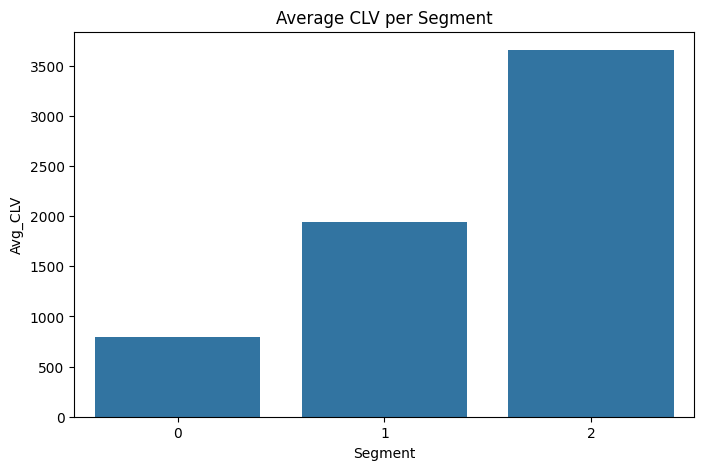

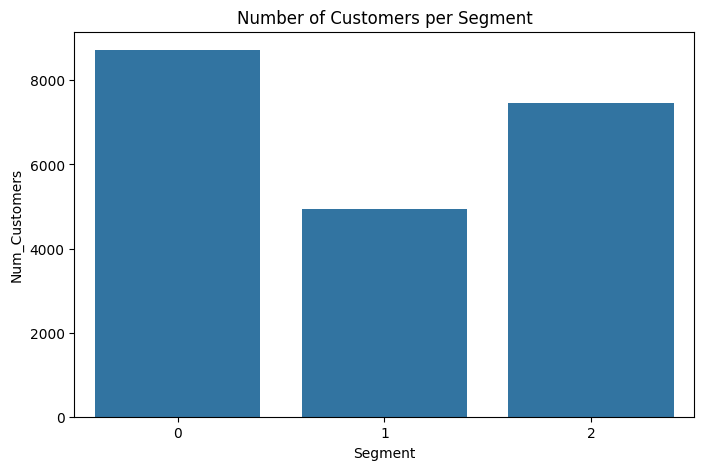

In [40]:
# CLV per segment
plt.figure(figsize=(8,5))
sns.barplot(x='Segment', y='Avg_CLV', data=segment_summary)
plt.title("Average CLV per Segment")
plt.show()

# Number of customers per segment
plt.figure(figsize=(8,5))
sns.barplot(x='Segment', y='Num_Customers', data=segment_summary)
plt.title("Number of Customers per Segment")
plt.show()

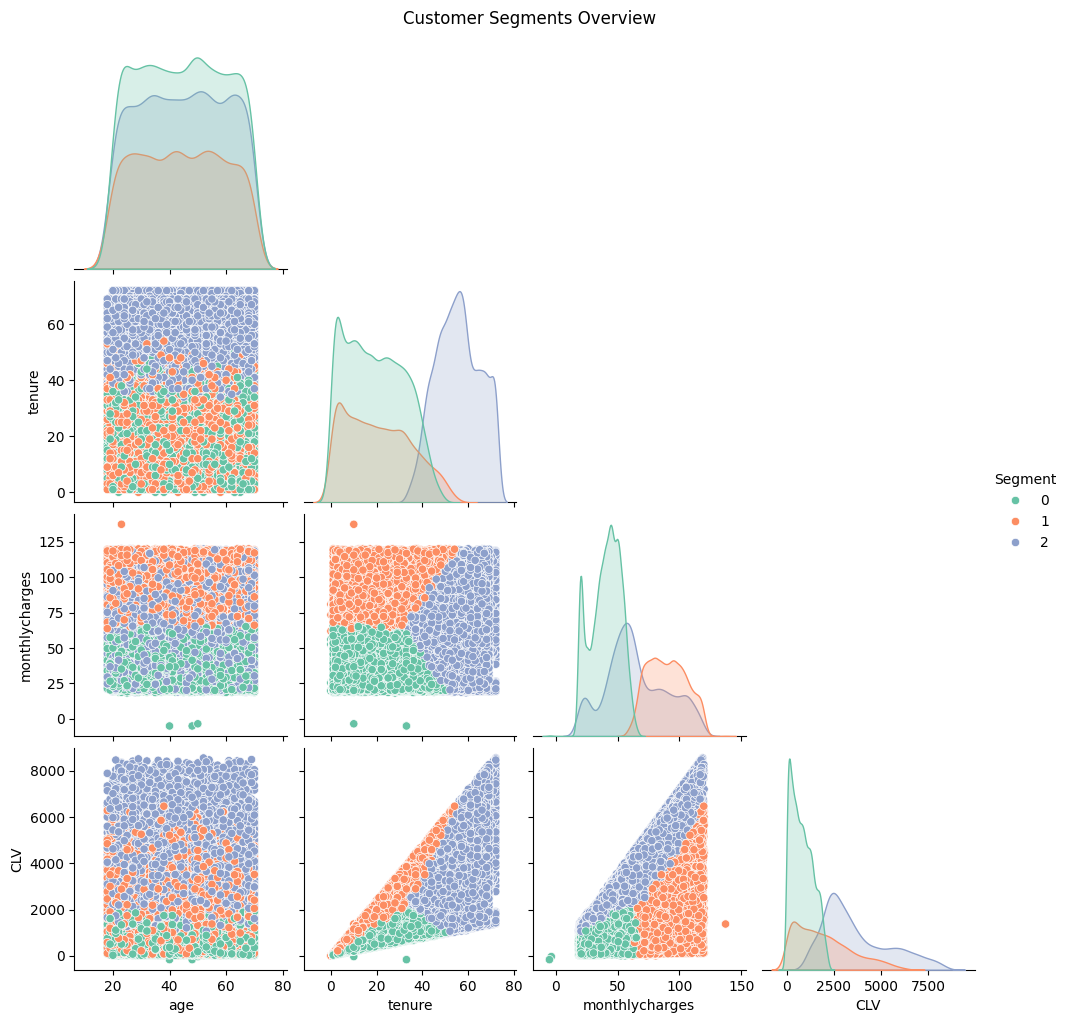

In [41]:
# Pairplot to see relationships between numeric features colored by Segment
numeric_features = ['age', 'tenure', 'monthlycharges', 'CLV']
sns.pairplot(df, vars=numeric_features, hue='Segment', palette='Set2', corner=True)
plt.suptitle("Customer Segments Overview", y=1.02)
plt.show()

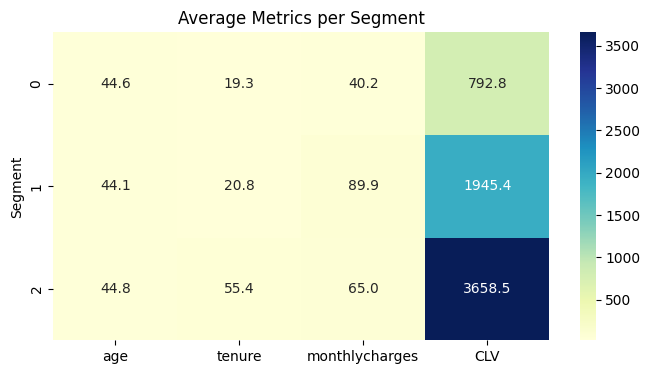

In [42]:
# Average metrics per segment
segment_avg = df.groupby('Segment')[numeric_features].mean()

plt.figure(figsize=(8,4))
sns.heatmap(segment_avg, annot=True, fmt=".1f", cmap='YlGnBu')
plt.title("Average Metrics per Segment")
plt.show()

In [43]:
score = silhouette_score(X_dense, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.16098269421685993


In [44]:
from sklearn.metrics import calinski_harabasz_score
ch_score = calinski_harabasz_score(X_dense, labels)
print("Calinski-Harabasz Index:", ch_score)

Calinski-Harabasz Index: 4217.361205024753


In [46]:
from sklearn.metrics import davies_bouldin_score
db_score = davies_bouldin_score(X_dense, labels)
print("Davies-Bouldin Index:", db_score)

Davies-Bouldin Index: 1.8081728623596753


In [ ]:
# Segment Labeling 

In [49]:
segment_summary[['Segment', 'Avg_CLV', 'Avg_Tenure', 'Avg_MonthlyCharges']]

,Segment,Avg_CLV,Avg_Tenure,Avg_MonthlyCharges
0,0,792.847039,19.339947,40.195779
1,1,1945.411145,20.768283,89.880339
2,2,3658.509190,55.433244,64.969440


In [51]:
# Example: label based on relative CLV
clv_mean = segment_summary['Avg_CLV'].mean()
clv_std = segment_summary['Avg_CLV'].std()

def label_segment_dynamic(row):
    if row['Avg_CLV'] > clv_mean + 0.5*clv_std:
        return 'High-value'
    elif row['Avg_CLV'] < clv_mean - 0.5*clv_std:
        return 'Low-value'
    else:
        return 'Medium-value'

segment_summary['Segment_Label'] = segment_summary.apply(label_segment_dynamic, axis=1)


In [54]:
# Create mapping from Segment to Segment_Label
segment_map = dict(zip(segment_summary['Segment'], segment_summary['Segment_Label']))

# Add Segment_Label to df
df['Segment_Label'] = df['Segment'].map(segment_map)

# Check first few rows
df[['customer_id', 'Segment', 'Segment_Label', 'CLV']].head()


,customer_id,Segment,Segment_Label,CLV
0,TEL_7590-VHVEG,0,Low-value,29.85
1,TEL_5575-GNVDE,0,Low-value,1936.30
2,TEL_3668-QPYBK,0,Low-value,107.70
3,TEL_7795-CFOCW,2,High-value,1903.50
4,TEL_9237-HQITU,1,Medium-value,141.40
...,...,...,...,...
995,TEL_3842-IYKUE,1,Medium-value,2985.50
996,TEL_6641-XRPSU,1,Medium-value,2380.00
997,TEL_1374-DMZUI,1,Medium-value,377.20
998,TEL_2545-LXYVJ,2,High-value,1490.40


In [55]:
# Calculate CLV thresholds
clv_mean = df['CLV'].mean()
clv_std = df['CLV'].std()

# Define "at-risk" customers as CLV below (mean - 0.5*std)
risk_threshold = clv_mean - 0.5*clv_std
df['At_Risk'] = df['CLV'] < risk_threshold

# Check how many are at risk
df['At_Risk'].value_counts()


At_Risk
False    12885
True      8244
Name: count, dtype: int64

In [56]:
# Filter churned customers
churn_customers = df[df['churn'] == 1][['customer_id', 'industry', 'Segment_Label', 'CLV']]

# Display the first few rows
churn_customers.head()


,customer_id,industry,Segment_Label,CLV
2,TEL_3668-QPYBK,Telecom,Low-value,107.7
4,TEL_9237-HQITU,Telecom,Medium-value,141.4
5,TEL_9305-CDSKC,Telecom,Medium-value,797.2
8,TEL_7892-POOKP,Telecom,Medium-value,2934.4
13,TEL_0280-XJGEX,Telecom,Medium-value,5081.3


In [57]:
# Count churned customers per segment and industry
churn_summary = churn_customers.groupby(['Segment_Label', 'industry']).agg({
    'customer_id': 'count',
    'CLV': ['mean', 'min']
}).reset_index()

churn_summary.columns = ['Segment', 'Industry', 'Num_Churned', 'Avg_CLV', 'Min_CLV']
churn_summary.sort_values(by='Num_Churned', ascending=False, inplace=True)
churn_summary


,Segment,Industry,Num_Churned,Avg_CLV,Min_CLV
4,Low-value,Subscription,2280,892.125952,-35.20
0,High-value,Ecommerce,1427,3684.690399,1074.31
6,Medium-value,Ecommerce,1250,2142.837232,67.49
8,Medium-value,Telecom,1193,1322.621961,59.20
1,High-value,Subscription,871,2530.070942,1590.24
3,Low-value,Ecommerce,863,797.007659,23.20
5,Low-value,Telecom,442,256.838122,18.85
2,High-value,Telecom,234,5004.984829,1046.75
7,Medium-value,Subscription,1,3995.160000,3995.16


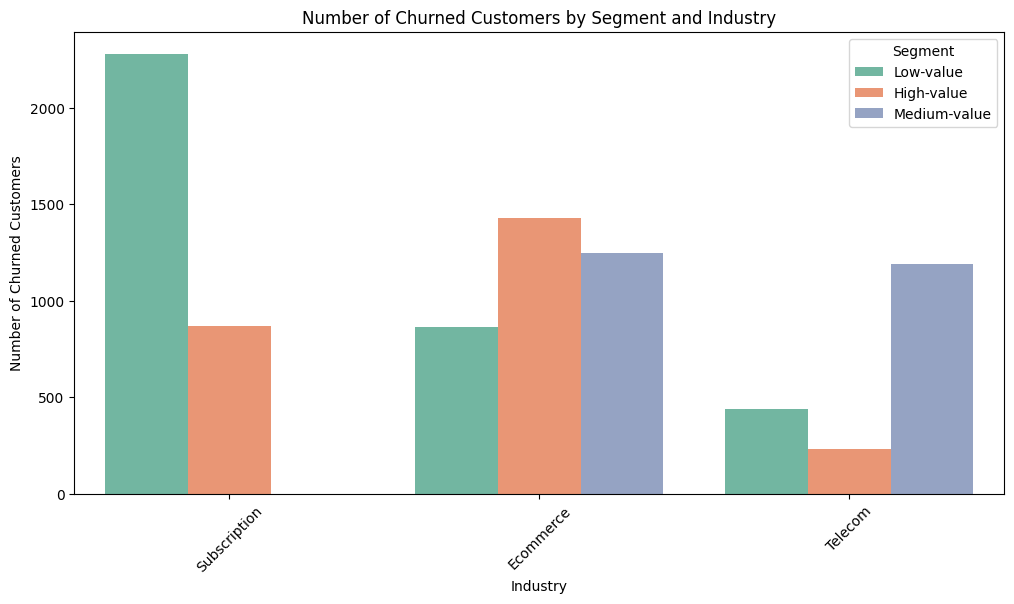

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.barplot(
    x='Industry',        # Matches churn_summary
    y='Num_Churned',
    hue='Segment',       # Matches churn_summary
    data=churn_summary,
    palette='Set2'
)
plt.title('Number of Churned Customers by Segment and Industry')
plt.xlabel('Industry')
plt.ylabel('Number of Churned Customers')
plt.xticks(rotation=45)
plt.legend(title='Segment')
plt.show()


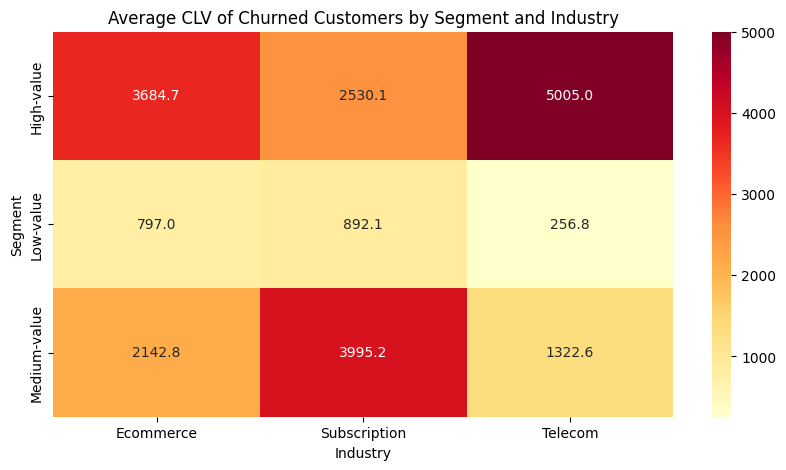

In [64]:
# Pivot table for heatmap
heatmap_data = churn_summary.pivot(index='Segment', columns='Industry', values='Avg_CLV')

plt.figure(figsize=(10,5))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap='YlOrRd')
plt.title('Average CLV of Churned Customers by Segment and Industry')
plt.xlabel('Industry')
plt.ylabel('Segment')
plt.show()


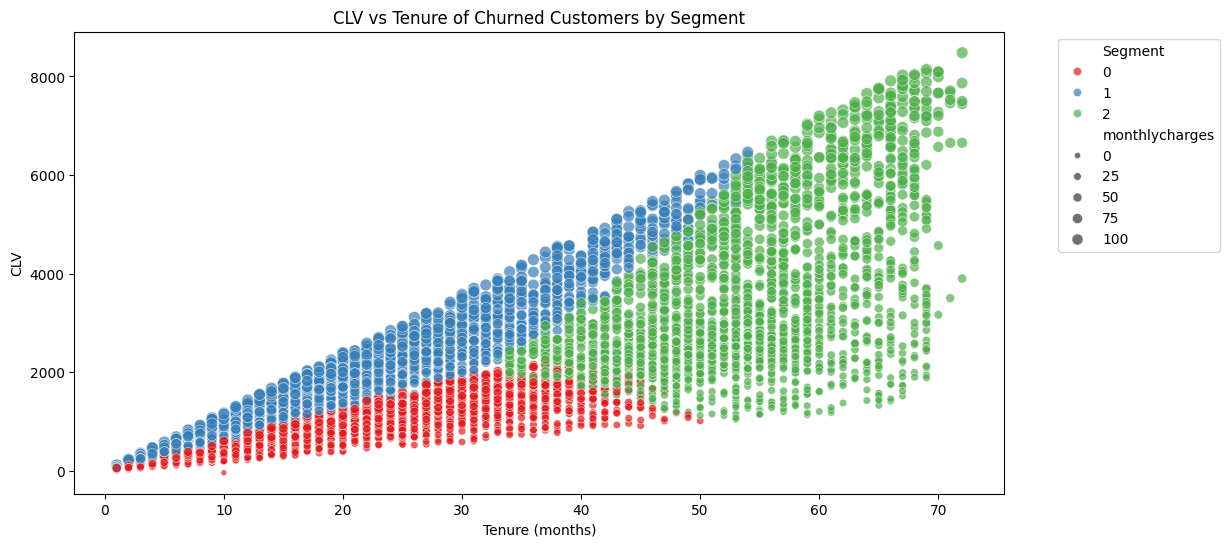

In [65]:
plt.figure(figsize=(12,6))
sns.scatterplot(
    x='tenure', 
    y='CLV', 
    hue='Segment', 
    size='monthlycharges',
    data=df[df['churn'] == 1],  # focus on churned customers
    alpha=0.7,
    palette='Set1'
)
plt.title('CLV vs Tenure of Churned Customers by Segment')
plt.xlabel('Tenure (months)')
plt.ylabel('CLV')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()


C:\Users\tomzs\AppData\Local\Temp\ipykernel_10376\1744204340.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Industry', y='Churn_Rate', data=churn_rate_industry, palette='coolwarm')


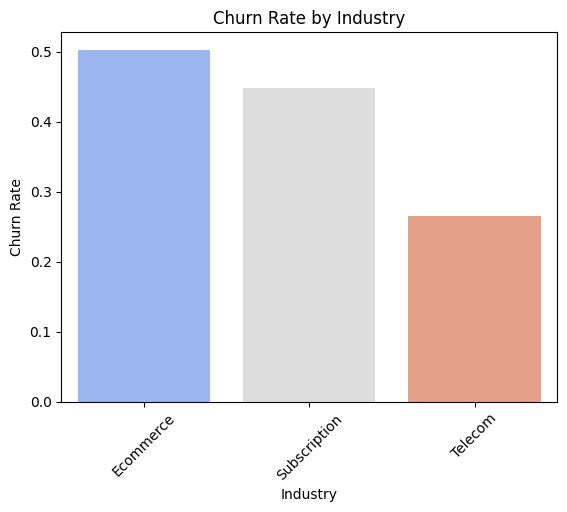

In [68]:
churn_rate_industry = df.groupby('industry')['churn'].mean().reset_index()
churn_rate_industry.columns = ['Industry', 'Churn_Rate']

sns.barplot(x='Industry', y='Churn_Rate', data=churn_rate_industry, palette='coolwarm')
plt.title('Churn Rate by Industry')
plt.ylabel('Churn Rate')
plt.xticks(rotation=45)
plt.show()


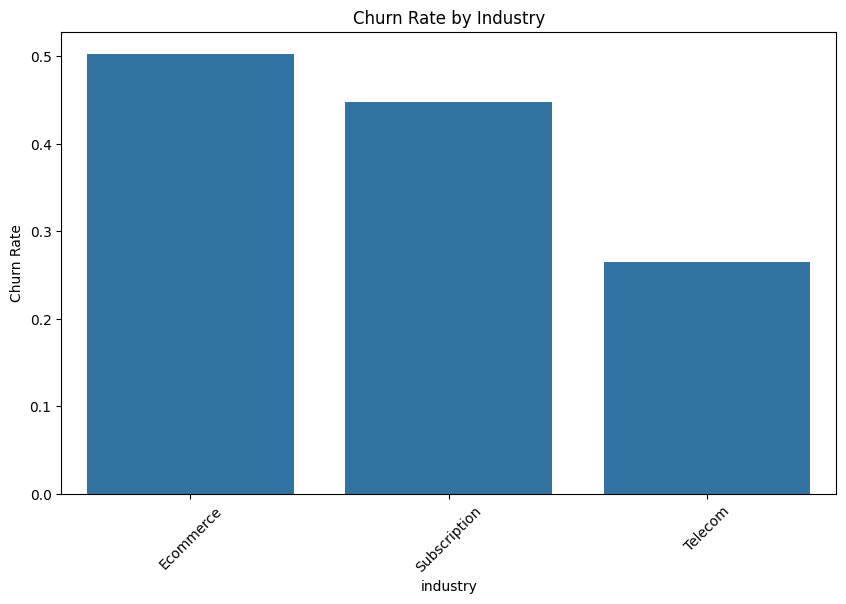

In [70]:
# Using the correct column name from df
churn_rate_industry = df.groupby('industry')['churn'].mean().reset_index()
churn_rate_industry.columns = ['industry', 'Churn_Rate']  # keep lowercase for consistency

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(x='industry', y='Churn_Rate', data=churn_rate_industry)
plt.title('Churn Rate by Industry')
plt.ylabel('Churn Rate')
plt.xticks(rotation=45)
plt.show()


In [ ]:
#Dashboard

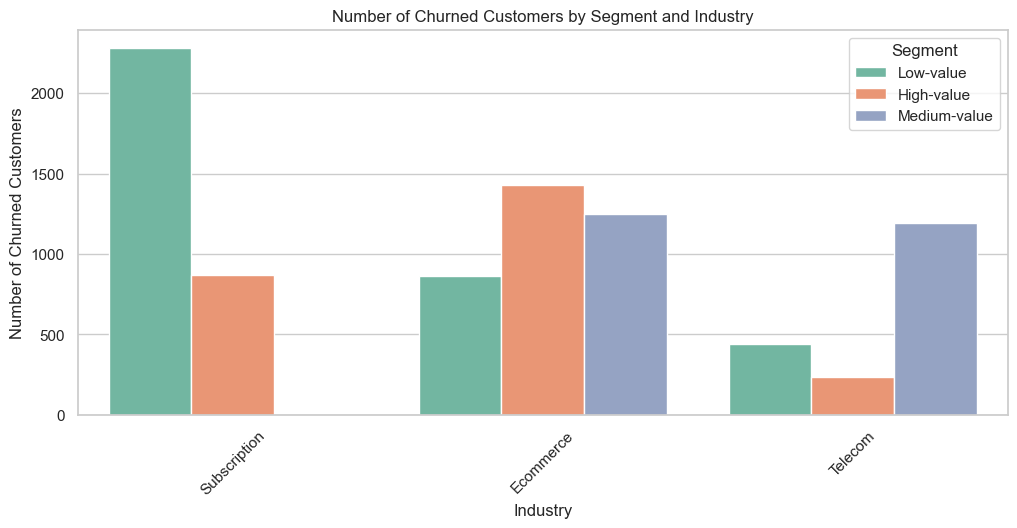

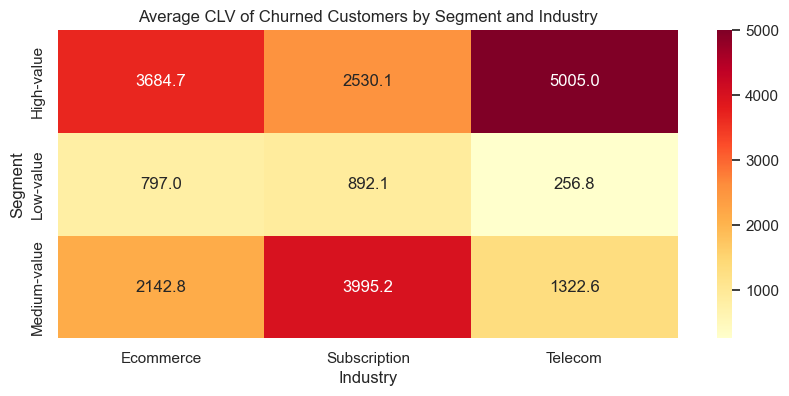

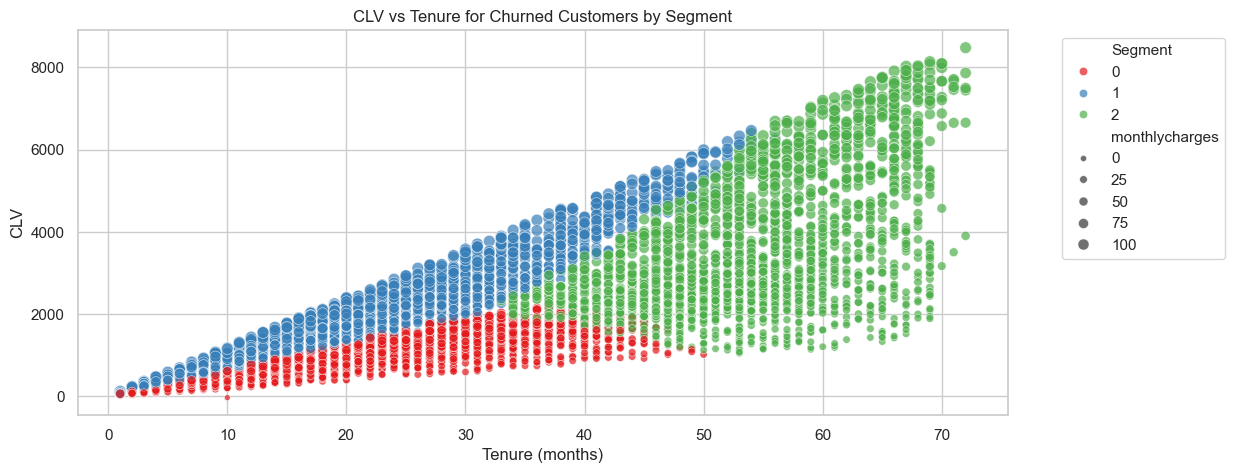

C:\Users\tomzs\AppData\Local\Temp\ipykernel_10376\2339293322.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='industry', y='Churn_Rate', data=churn_rate_industry, palette='coolwarm')


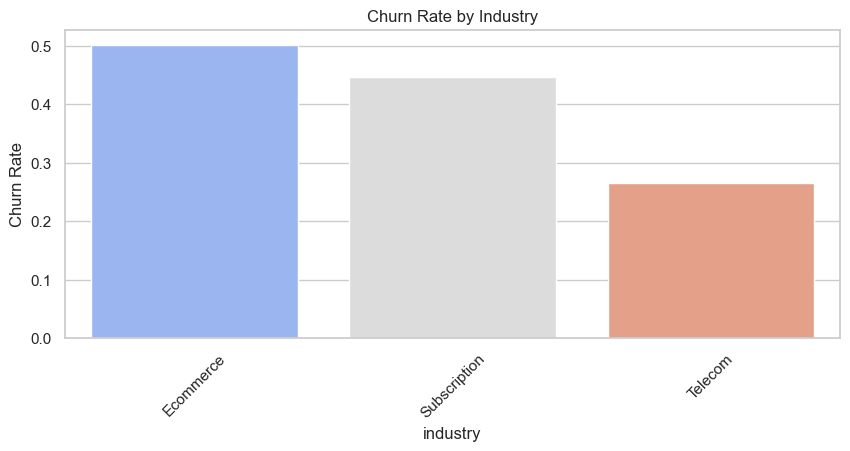

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set(style="whitegrid")

# -----------------------------
# 1️⃣ Bar Chart: Number of churned customers by Segment + Industry
# -----------------------------
plt.figure(figsize=(12,5))
sns.barplot(
    x='Industry',       # Column in churn_summary
    y='Num_Churned',
    hue='Segment',
    data=churn_summary,
    palette='Set2'
)
plt.title('Number of Churned Customers by Segment and Industry')
plt.xlabel('Industry')
plt.ylabel('Number of Churned Customers')
plt.xticks(rotation=45)
plt.legend(title='Segment')
plt.show()

# -----------------------------
# 2️⃣ Heatmap: Average CLV of churned customers
# -----------------------------
heatmap_data = churn_summary.pivot(index='Segment', columns='Industry', values='Avg_CLV')
plt.figure(figsize=(10,4))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap='YlOrRd')
plt.title('Average CLV of Churned Customers by Segment and Industry')
plt.xlabel('Industry')
plt.ylabel('Segment')
plt.show()

# -----------------------------
# 3️⃣ Scatter Plot: CLV vs Tenure for churned customers
# -----------------------------
plt.figure(figsize=(12,5))
sns.scatterplot(
    x='tenure',
    y='CLV',
    hue='Segment',           # From df
    size='monthlycharges',   # Optional: shows monthly revenue
    data=df[df['churn']==1], # Only churned customers
    alpha=0.7,
    palette='Set1'
)
plt.title('CLV vs Tenure for Churned Customers by Segment')
plt.xlabel('Tenure (months)')
plt.ylabel('CLV')
plt.legend(bbox_to_anchor=(1.05,1), loc=2)
plt.show()

# -----------------------------
# 4️⃣ Bar Chart: Churn rate per industry
# -----------------------------
churn_rate_industry = df.groupby('industry')['churn'].mean().reset_index()
churn_rate_industry.columns = ['industry', 'Churn_Rate']

plt.figure(figsize=(10,4))
sns.barplot(x='industry', y='Churn_Rate', data=churn_rate_industry, palette='coolwarm')
plt.title('Churn Rate by Industry')
plt.ylabel('Churn Rate')
plt.xticks(rotation=45)
plt.show()


In [83]:
import pandas as pd
import plotly.express as px
import plotly.io as pio

# -----------------------------
# Set Plotly renderer for Jupyter Notebook
# -----------------------------
pio.renderers.default = "notebook_connected"

# -----------------------------
# 1️⃣ Prepare Data
# -----------------------------
# Clip negative monthly charges for marker size
df['monthlycharges_clipped'] = df['monthlycharges'].clip(lower=0)

# Ensure proper string type for categorical columns
df['Segment'] = df['Segment'].astype(str)
df['industry'] = df['industry'].astype(str)
churn_summary['Segment'] = churn_summary['Segment'].astype(str)
churn_summary['Industry'] = churn_summary['Industry'].astype(str)

# -----------------------------
# 2️⃣ Bar Chart: Number of Churned Customers by Segment + Industry
# -----------------------------
fig1 = px.bar(
    churn_summary,
    x='Industry',
    y='Num_Churned',
    color='Segment',
    barmode='group',
    title='Number of Churned Customers by Segment and Industry',
    labels={'Num_Churned':'Number of Churned Customers'}
)
fig1.show()

# -----------------------------
# 3️⃣ Heatmap: Average CLV of Churned Customers
# -----------------------------
heatmap_data = churn_summary.pivot(index='Segment', columns='Industry', values='Avg_CLV')

fig2 = px.imshow(
    heatmap_data,
    text_auto=True,
    color_continuous_scale='YlOrRd',
    labels=dict(x="Industry", y="Segment", color="Avg CLV"),
    title="Average CLV of Churned Customers by Segment and Industry"
)
fig2.show()

# -----------------------------
# 4️⃣ Scatter Plot: CLV vs Tenure for Churned Customers
# -----------------------------
fig3 = px.scatter(
    df[df['churn']==1],
    x='tenure',
    y='CLV',
    color='Segment',
    size='monthlycharges_clipped',
    hover_data=['customer_id','industry','monthlycharges'],
    title='CLV vs Tenure for Churned Customers by Segment'
)
fig3.show()

# -----------------------------
# 5️⃣ Bar Chart: Churn Rate per Industry
# -----------------------------
churn_rate_industry = df.groupby('industry')['churn'].mean().reset_index()
churn_rate_industry.columns = ['industry', 'Churn_Rate']

fig4 = px.bar(
    churn_rate_industry,
    x='industry',
    y='Churn_Rate',
    color='Churn_Rate',
    color_continuous_scale='RdYlGn_r',
    title='Churn Rate by Industry'
)
fig4.show()


In [79]:
critical_customers = df[(df['At_Risk']==True) & (df['churn']==0)]
critical_customers = critical_customers.sort_values(by='CLV', ascending=False)
critical_customers[['customer_id','Segment','industry','CLV','tenure']]


,customer_id,Segment,industry,CLV,tenure
9185,SUBS_2143,0,Subscription,1165.080000,28
19008,ECOM_51,0,Ecommerce,1164.840000,34
7964,SUBS_922,0,Subscription,1164.720000,24
9885,SUBS_2843,0,Subscription,1163.800000,22
18993,ECOM_92,0,Ecommerce,1163.520000,24
...,...,...,...,...,...
1082,TEL_4367-NUYAO,0,Telecom,0.000000,0
4380,TEL_2520-SGTTA,0,Telecom,0.000000,0
6754,TEL_2775-SEFEE,1,Telecom,0.000000,0
12631,SUBS_1354,0,Subscription,-166.979975,33
